# Chapter 4

## Lab: The Stock Market Data

In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

In [3]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
    (LinearDiscriminantAnalysis as LDA,
     QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [4]:
smarket = load_data('Smarket')
smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


In [5]:
smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [6]:
smarket.select_dtypes(include='number').corr()
# when using smarket.corr() we got error because Direction row contains Qualitative data

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


<Axes: >

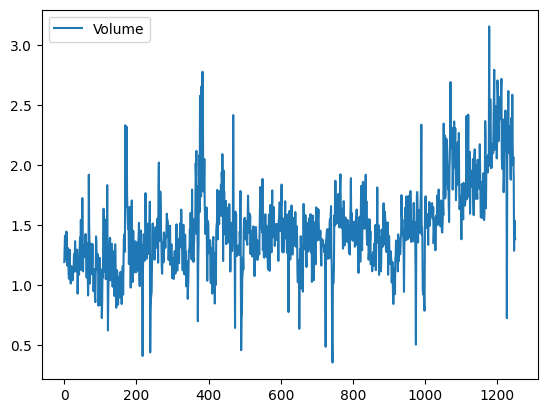

In [7]:
smarket.plot(y='Volume')

## Logistic Regression

In [8]:
#fit a logistic regression model in order to predict Direction using Lag1-5 and volume
allvars = smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(smarket)
y = smarket.Direction == 'Up'
#sm.GLM fits generalized linear models, alternatively we can use sm.Logit() to fit logistic directly
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
#family=sm.families.Binomial() tells to select logistic from generalized models
results_0 = glm.fit()
summarize(results_0)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


as p value is relatively high, there is no clear evidence of a real association betn last days or volume with Direction

In [9]:
probs = results_0.predict()
probs

array([0.50708413, 0.48146788, 0.48113883, ..., 0.5392683 , 0.52611829,
       0.51791656], shape=(1250,))

In [10]:
#convert prob into class labels, up or down
labels = np.array(['Down']*1250)
labels[probs>0.5] = "Up"
labels

array(['Up', 'Down', 'Down', ..., 'Up', 'Up', 'Up'],
      shape=(1250,), dtype='<U4')

In [11]:
confusion_table(labels, smarket.Direction)

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


In [12]:
(145+507)/1250, np.mean(labels == smarket.Direction)

(0.5216, np.float64(0.5216))

now lets train our model first then predict, use 2001-2004 to train and predict 2005

In [13]:
train = (smarket.Year < 2005)
smarket_train = smarket.loc[train]
smarket_test = smarket.loc[~train]
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)
probs


998     0.528220
999     0.515669
1000    0.522652
1001    0.513854
1002    0.498334
          ...   
1245    0.483637
1246    0.506048
1247    0.516658
1248    0.516124
1249    0.508072
Length: 252, dtype: float64

now we compare the predictions

In [14]:
D = smarket.Direction
L_train, L_test = D.loc[train], D.loc[~train]

In [15]:
labels = np.array(['Down']*252)
labels[probs>0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


In [16]:
(77+44)/252

0.4801587301587302

this shows that test accuracy is about 48% while error rate is about 52%

In [17]:
np.mean(labels == L_test), np.mean(labels != L_test)


(np.float64(0.4801587301587302), np.float64(0.5198412698412699))

from previous table, we had known that lag1-5 didn't have that much influence on Direction so now lets try removing the least effective ones 3-5 and just keep lag1 and lag2 to train our data and see what happens


In [18]:
model = MS(['Lag1', 'Lag2']).fit(smarket)
X = model.transform(smarket)
X_train, X_test = X.loc[train], X.loc[~train]
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)
labels = np.array(['Down']*252)
labels[probs>0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [19]:
newdata = pd.DataFrame({'Lag1':[1.2, 1.5],
                        'Lag2':[1.1, -0.8]});
newX = model.transform(newdata)
results.predict(newX)


0    0.479146
1    0.496094
dtype: float64

## Linear Discriminant Analysis

In [20]:
lda = LDA(store_covariance=True)
#it tells to store covariance matrix instead of discarding them

In [21]:
#remove intercept from xtrain and xtest
X_train, X_test = [M.drop(columns = ['intercept'])
                   for M in [X_train, X_test]]
lda.fit(X_train, L_train)
                            
                            

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [22]:
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [23]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [24]:
lda.priors_


array([0.49198397, 0.50801603])

In [25]:
lda. scalings_

array([[-0.64201904],
       [-0.51352928]])

In [26]:
lda_pred = lda.predict(X_test)

In [27]:
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [28]:
np.mean(lda_pred == L_test), np.mean(lda_pred != L_test)

(np.float64(0.5595238095238095), np.float64(0.44047619047619047))

the accuracy increased upto almost 56% which is quite high considering we are predicting stock market

In [30]:
# if we want to change posterior prob threshold other than 50%, suppoose 90%
lda_prob = lda.predict_proba(X_test)
np.sum(lda_prob[:,0] > 0.9)


np.int64(0)

this shows that there are no days in 2005 in which prob is higher than 90% of market going down, as down is first column in the classes

## Quadratic Discriminant Analysis

In [31]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",True
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [32]:
#means return the mean value of lag1 and lag2 for down and up class, row 1 is for down and 2 is for up
#priors returns the how common each class is in our training data
qda.means_, qda.priors_

(array([[ 0.04279022,  0.03389409],
        [-0.03954635, -0.03132544]]),
 array([0.49198397, 0.50801603]))

In [33]:
#this returns covaraiance matrix for down class
qda.covariance_[0]

array([[ 1.50662277, -0.03924806],
       [-0.03924806,  1.53559498]])

In [34]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,30,20
Up,81,121


In [35]:
np.mean(qda_pred == L_test)

np.float64(0.5992063492063492)

the accuracy increased upto 59%, which was 56% in LDA

## Naive Bayes

In [36]:
nb = GaussianNB()
nb.fit(X_train, L_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [37]:
nb.classes_

array(['Down', 'Up'], dtype='<U4')

In [38]:
nb.class_prior_

array([0.49198397, 0.50801603])

In [39]:
nb.theta_
#same as mean for lda and qda

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [40]:
nb.var_

array([[1.50355429, 1.53246749],
       [1.51401364, 1.48732877]])

In [41]:
nb?


Type:        GaussianNB
String form: GaussianNB()
File:        f:\online courses\islp\islp_env\lib\site-packages\sklearn\naive_bayes.py
Docstring:  
Gaussian Naive Bayes (GaussianNB).

Can perform online updates to model parameters via :meth:`partial_fit`.
For details on algorithm used to update feature means and variance online,
see `Stanford CS tech report STAN-CS-79-773 by Chan, Golub, and LeVeque
<http://i.stanford.edu/pub/cstr/reports/cs/tr/79/773/CS-TR-79-773.pdf>`_.

Read more in the :ref:`User Guide <gaussian_naive_bayes>`.

Parameters
----------
priors : array-like of shape (n_classes,), default=None
    Prior probabilities of the classes. If specified, the priors are not
    adjusted according to the data.

var_smoothing : float, default=1e-9
    Portion of the largest variance of all features that is added to
    variances for calculation stability.

    .. versionadded:: 0.20

Attributes
----------
class_count_ : ndarray of shape (n_classes,)
    number of training samples 

In [42]:
nb_labels = nb.predict(X_test)
confusion_table(nb_labels, L_test)

Truth,Down,Up
Predicted,,
Down,29,20
Up,82,121


In [43]:
np.mean(nb_labels == L_test)

np.float64(0.5952380952380952)

it also gives overall accuracy of 59%

In [44]:
nb.predict_proba(X_test)[:5]
#returns probability for each observation

array([[0.4873288 , 0.5126712 ],
       [0.47623584, 0.52376416],
       [0.46529531, 0.53470469],
       [0.47484469, 0.52515531],
       [0.49020587, 0.50979413]])

## K-Nearest Neighbors

In [45]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

Truth,Down,Up
Predicted,,
Down,43,58
Up,68,83


In [46]:
np.mean(knn1_pred == L_test)

np.float64(0.5)

it just gave 50% accuracy, which is not enough so lets see by increasing the K =3

In [47]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, L_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [49]:
knn3_pred = knn3.predict(X_test)
np.mean(knn3_pred == L_test)

np.float64(0.5317460317460317)

the results slightly improved but this stock market data is not suitable for kneighbour classifier

lets try this on Caravan data set of ISLP package

In [53]:
caravan = load_data('Caravan')
purchase = caravan.Purchase
purchase.value_counts()

Purchase
No     5474
Yes     348
Name: count, dtype: int64

In [56]:
feature_df = caravan.drop(columns=['Purchase'])

we need to standardize the data, otherwise we might get issue as scale is different for each parameters

In [58]:
scaler = StandardScaler(with_mean=True,
                        with_std=True,
                        copy=True)
#all these three parameters are true by default, so we are good without mentioning them here

In [ ]:
scaler.fit(feature_df)
#it computes mean and standard deviation internally

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
#transformation happens here Xnew = (x-mean)/sd
X_std = scaler.transform(feature_df)
X_std

array([[ 0.68090623, -0.27257995,  0.40669664, ..., -0.15062046,
        -0.08734772, -0.11881647],
       [ 0.99229684, -0.27257995, -0.85950007, ..., -0.15062046,
        -0.08734772, -0.11881647],
       [ 0.99229684, -0.27257995, -0.85950007, ..., -0.15062046,
        -0.08734772, -0.11881647],
       ...,
       [ 0.68090623, -0.27257995,  0.40669664, ..., -0.15062046,
        -0.08734772, -0.11881647],
       [ 0.75875388, -0.27257995,  0.40669664, ..., -0.15062046,
        -0.08734772, -0.11881647],
       [ 0.68090623, -0.27257995,  0.40669664, ..., -0.15062046,
        -0.08734772, -0.11881647]], shape=(5822, 85))

In [ ]:
#converting it to df again
feature_std = pd.DataFrame(
                X_std,
                columns=feature_df.columns);
feature_std


,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,ALEVEN,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND
0,0.680906,-0.27258,0.406697,-1.216964,0.779405,-0.694311,0.217444,-0.068711,-0.161816,0.427670,...,-0.202910,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
1,0.992297,-0.27258,-0.859500,-1.216964,0.779405,0.302552,-0.365410,-0.068711,0.464159,-0.096077,...,-0.202910,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
2,0.992297,-0.27258,-0.859500,-1.216964,0.779405,-0.694311,-0.365410,0.914172,0.464159,-1.667319,...,-0.202910,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
3,-1.187437,-0.27258,0.406697,0.010755,-0.970980,1.299414,-0.948264,0.914172,0.464159,-0.619824,...,-0.202910,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
4,1.225840,-0.27258,1.672893,-1.216964,1.479559,0.302552,-0.365410,-0.068711,0.464159,0.427670,...,-0.202910,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5817,0.914449,-0.27258,-2.125697,-1.216964,0.779405,-0.694311,0.800298,-0.068711,-0.787790,-2.714813,...,5.094585,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
5818,0.836602,-0.27258,1.672893,1.238473,0.779405,0.302552,-0.365410,-0.068711,0.464159,-0.096077,...,-0.202910,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
5819,0.680906,-0.27258,0.406697,1.238473,0.779405,-0.694311,0.800298,-1.051594,-0.161816,-0.619824,...,-0.202910,-0.073165,-0.081055,-0.05992,0.764971,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816
5820,0.758754,-0.27258,0.406697,-1.216964,0.779405,-0.694311,1.383152,-1.051594,-0.787790,0.427670,...,-0.202910,-0.073165,-0.081055,-0.05992,-1.014358,-0.022706,-0.07365,-0.15062,-0.087348,-0.118816


In [66]:
feature_std.std()

MOSTYPE     1.000086
MAANTHUI    1.000086
MGEMOMV     1.000086
MGEMLEEF    1.000086
MOSHOOFD    1.000086
              ...   
AZEILPL     1.000086
APLEZIER    1.000086
AFIETS      1.000086
AINBOED     1.000086
ABYSTAND    1.000086
Length: 85, dtype: float64

.std() returns sd larger than 1, because pandas uses sample std while standardscaler uses population std formula

In [67]:
(X_train, X_test, y_train, y_test) = train_test_split(feature_std,
                                                      purchase,
                                                      test_size=1000,
                                                      random_state=0)

In [75]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1_pred = knn1.fit(X_train, y_train).predict(X_test)
np.mean(y_test != knn1_pred), np.mean(y_test != 'No')


(np.float64(0.111), np.float64(0.067))

error rate is just 11% but the sample of yes in the entire dataset is only 6.67%, we can simply always predict no and get error rate down to 6.67%, so we need to change something

In [76]:
confusion_table(knn1_pred, y_test)

Truth,No,Yes
Predicted,,
No,880,58
Yes,53,9


In [77]:
9/(53+9)


0.14516129032258066

the success rate for predicting yes is 14.5% which is higher than random guessing

In [97]:
#try to get success rate for diff values of k (1-5)
for k in range(1,6):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    C = confusion_table(knn_pred, y_test)
    templ = ('K={0:d}: # predicted to purchase: {1:>2},' +
             ' # who did purchase {2:d}, accuracy {3:.1%}')
    pred = C.loc['Yes'].sum()
    did_purchase = C.loc['Yes', 'Yes']
    print(templ.format(
            k,
            pred,
            did_purchase,
            did_purchase / pred))
    

K=1: # predicted to purchase: 62, # who did purchase 9, accuracy 14.5%
K=2: # predicted to purchase:  6, # who did purchase 1, accuracy 16.7%
K=3: # predicted to purchase: 20, # who did purchase 3, accuracy 15.0%
K=4: # predicted to purchase:  4, # who did purchase 0, accuracy 0.0%
K=5: # predicted to purchase:  7, # who did purchase 1, accuracy 14.3%


comparison to logistic regression

In [105]:
logit = LogisticRegression(C=1e10, solver='liblinear')
logit.fit(X_train, y_train)
logit_pred = logit.predict_proba(X_test)
logit_labels = np.where(logit_pred[:,1] > 0.5, 'Yes', 'No')
confusion_table(logit_labels, y_test)


Truth,No,Yes
Predicted,,
No,931,67
Yes,2,0


In [106]:
logit_labels = np.where(logit_pred[:, 1] > 0.25, 'Yes', 'No')
confusion_table(logit_labels, y_test)

Truth,No,Yes
Predicted,,
No,913,58
Yes,20,9


## Linear and Poisson Regression on the Bikeshare Data

In [114]:
bike = load_data('Bikeshare')


Linear Regression

In [111]:
X = MS(['mnth',
        'hr',
        'workingday',
        'temp',
        'weathersit']).fit_transform(bike)
Y = bike['bikers']
M_lm = sm.OLS(Y, X).fit()
summarize(M_lm)

,coef,std err,t,P>|t|
intercept,-68.6317,5.307,-12.932,0.000
mnth[Feb],6.8452,4.287,1.597,0.110
mnth[March],16.5514,4.301,3.848,0.000
mnth[April],41.4249,4.972,8.331,0.000
mnth[May],72.5571,5.641,12.862,0.000
mnth[June],67.8187,6.544,10.364,0.000
mnth[July],45.3245,7.081,6.401,0.000
mnth[Aug],53.2430,6.640,8.019,0.000
mnth[Sept],66.6783,5.925,11.254,0.000
mnth[Oct],75.8343,4.950,15.319,0.000


In [116]:
#contrast with sum made coeff represent deviaiton from overall mean, before first one was used as a basis i.e. jan
hr_encode = contrast('hr', 'sum')
mnth_encode = contrast('mnth', 'sum')

In [117]:
X2 = MS([mnth_encode,
         hr_encode,
         'workingday',
         'temp',
         'weathersit']).fit_transform(bike)
M2_lm = sm.OLS(Y, X2).fit()
S2 = summarize(M2_lm)
S2

,coef,std err,t,P>|t|
intercept,73.5974,5.132,14.340,0.000
mnth[Jan],-46.0871,4.085,-11.281,0.000
mnth[Feb],-39.2419,3.539,-11.088,0.000
mnth[March],-29.5357,3.155,-9.361,0.000
mnth[April],-4.6622,2.741,-1.701,0.089
mnth[May],26.4700,2.851,9.285,0.000
mnth[June],21.7317,3.465,6.272,0.000
mnth[July],-0.7626,3.908,-0.195,0.845
mnth[Aug],7.1560,3.535,2.024,0.043
mnth[Sept],20.5912,3.046,6.761,0.000


in this model too, dec is missing but we know sum of coeff is 0, so we can use that to calculate that

In [125]:
coef_month = S2.loc[S2.index.str.contains('mnth'),'coef']
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
Name: coef, dtype: float64

In [127]:
coef_month = pd.concat([
    coef_month,
    pd.Series([-coef_month.sum()],
              index = ['mnth(Dec])'])
])
coef_month

mnth[Jan]     -46.0871
mnth[Feb]     -39.2419
mnth[March]   -29.5357
mnth[April]    -4.6622
mnth[May]      26.4700
mnth[June]     21.7317
mnth[July]     -0.7626
mnth[Aug]       7.1560
mnth[Sept]     20.5912
mnth[Oct]      29.7472
mnth[Nov]      14.2229
mnth(Dec])      0.3705
dtype: float64

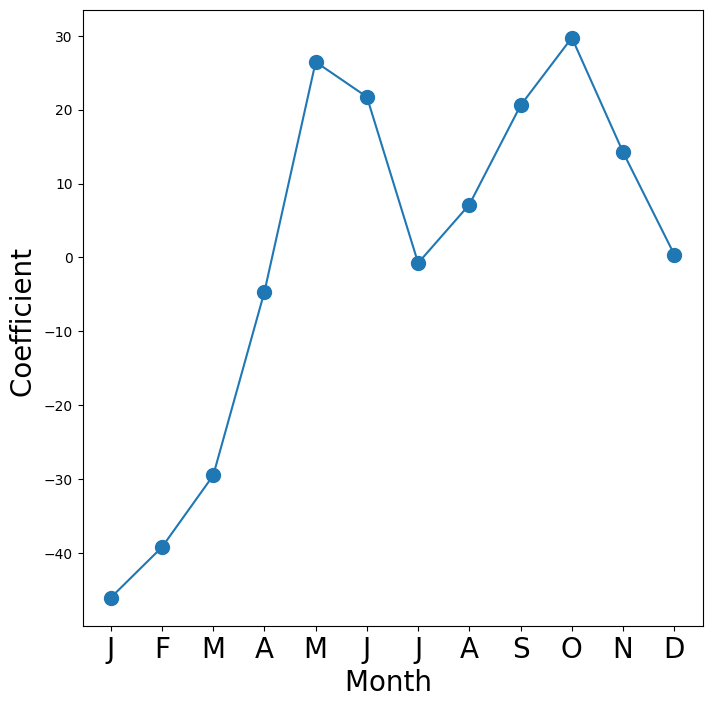

In [128]:
fig_month , ax_month = subplots(figsize =(8 ,8))
x_month = np.arange(coef_month.shape [0])
ax_month.plot(x_month , coef_month , marker='o', ms=10)
ax_month.set_xticks(x_month)
ax_month.set_xticklabels ([l[5] for l in coef_month.index], fontsize
=20)
ax_month.set_xlabel('Month ', fontsize =20)
ax_month.set_ylabel('Coefficient ', fontsize =20);

poisson regression

In [129]:
M_pois = sm.GLM(Y, X2 , family=sm.families.Poisson ()).fit()